# A Statistical Analysis of Beer Pong

## 1. Imports and configuration

In [35]:
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass
from math import factorial
from typing import Iterable

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "figure.dpi": 120,
})

SEED = 2020
GRID_SIZE = 9
WINNING_SCORE = 6

MISS, RIM, CUP = 0, 1, 2
DIRECTIONS = np.array([(0, -1), (-1, 0), (0, 1), (1, 0)])

CUP_COORDINATES = (
    (2, 2), (2, 4), (2, 6),
    (4, 3), (4, 5),
    (6, 4),
)

RIM_COORDINATES = (
    (1, 2), (1, 4), (1, 6),
    (2, 1), (2, 3), (2, 5), (2, 7),
    (3, 2), (3, 3), (3, 4), (3, 5), (3, 6),
    (4, 2), (4, 4), (4, 6),
    (5, 3), (5, 4), (5, 5),
    (6, 3), (6, 5),
    (7, 4),
)

PAPER_EVENT_TIMES = np.array([
    0.0, 4.6880, 10.6093, 18.1332, 28.2148, 43.1115, 66.8165
])

## 2. Simulation engine

A throw begins at one of the 81 grid cells with equal probability. A direct cup hit scores. A direct miss changes the turn. A rim hit initiates an equal-probability random walk left, up, right, or down until the ball reaches either a cup or a non-cup cell. A make grants another throw; a miss passes the turn.

In [36]:
def initial_grid() -> np.ndarray:
    '''Return the paper's 9x9 six-cup rack.'''
    grid = np.full((GRID_SIZE, GRID_SIZE), MISS, dtype=np.int8)
    for coordinate in RIM_COORDINATES:
        grid[coordinate] = RIM
    for coordinate in CUP_COORDINATES:
        grid[coordinate] = CUP
    return grid


@dataclass
class Rack:
    '''A mutable target rack belonging to one player.'''
    def __post_init__(self) -> None:
        self.grid = initial_grid()

    @property
    def cups_remaining(self) -> int:
        return int(np.count_nonzero(self.grid == CUP))

    def remove_cup(self, row: int, column: int) -> None:
        '''Remove a made cup and the rim cells no longer supported by cups.'''
        if self.grid[row, column] != CUP:
            raise ValueError(f"No cup exists at {(row, column)}")

        self.grid[row, column] = MISS
        self.grid[row - 1, column] = MISS
        self.grid[row + 1, column] = MISS

        if (row, column) == (2, 2):
            self.grid[2, 1] = MISS
            if self.grid[2, 4] == MISS:
                self.grid[2, 3] = MISS
        elif (row, column) == (2, 4):
            if self.grid[2, 2] == MISS:
                self.grid[2, 3] = MISS
            if self.grid[2, 6] == MISS:
                self.grid[2, 5] = MISS
        elif (row, column) == (2, 6):
            self.grid[2, 7] = MISS
            if self.grid[2, 4] == MISS:
                self.grid[2, 5] = MISS
        elif (row, column) == (4, 3):
            self.grid[4, 2] = MISS
            if self.grid[4, 5] == MISS:
                self.grid[4, 4] = MISS
        elif (row, column) == (4, 5):
            self.grid[4, 6] = MISS
            if self.grid[4, 3] == MISS:
                self.grid[4, 4] = MISS
        elif (row, column) == (6, 4):
            self.grid[6, 3] = MISS
            self.grid[6, 5] = MISS


@dataclass(frozen=True)
class ShotResult:
    scored: bool
    kind: str
    start: tuple[int, int]
    end: tuple[int, int]
    bounces: int


@dataclass(frozen=True)
class ThrowRecord:
    global_throw: int
    player: int
    player_attempt: int
    shot_kind: str
    scored: bool
    player1_score: int
    player2_score: int


@dataclass
class GameResult:
    first_player: int
    winner: int
    attempts: tuple[int, int]
    event_times: tuple[tuple[int, ...], tuple[int, ...]]
    records: tuple[ThrowRecord, ...]

    @property
    def final_scores(self) -> tuple[int, int]:
        return (
            self.records[-1].player1_score,
            self.records[-1].player2_score,
        )

    @property
    def score_differences(self) -> np.ndarray:
        return np.array(
            [0] + [r.player1_score - r.player2_score for r in self.records]
        )

    @property
    def max_absolute_lead(self) -> int:
        return int(np.abs(self.score_differences).max())

    @property
    def final_margin(self) -> int:
        return int(abs(self.final_scores[0] - self.final_scores[1]))

    @property
    def game_type(self) -> str:
        if self.max_absolute_lead <= 3:
            return "Neck and neck"
        if self.final_margin <= 3:
            return "Apparent choke"
        return "Landslide"

    @property
    def signed_biggest_lead(self) -> int:
        differences = self.score_differences
        positive = int(differences.max())
        negative = int(differences.min())
        if positive > abs(negative):
            return positive
        if abs(negative) > positive:
            return negative
        return 0

    @property
    def surprise_type(self) -> str:
        lead = self.signed_biggest_lead
        if lead == 0:
            return "Other"
        leader = 1 if lead > 0 else 2
        return "No surprise" if leader == self.winner else "Surprise"

    def history_frame(self) -> pd.DataFrame:
        return pd.DataFrame([record.__dict__ for record in self.records])

In [37]:
def simulate_shot(rack: Rack, rng: np.random.Generator) -> ShotResult:
    '''Simulate one throw at a rack and mutate the rack after a make.'''
    row, column = map(int, rng.integers(0, GRID_SIZE, size=2))
    start = (row, column)
    hit_rim = rack.grid[row, column] == RIM
    bounces = 0

    while rack.grid[row, column] == RIM:
        delta_row, delta_column = DIRECTIONS[int(rng.integers(0, 4))]
        row += int(delta_row)
        column += int(delta_column)
        bounces += 1
        if bounces > 10_000:
            raise RuntimeError("Rim random walk did not terminate")

    scored = rack.grid[row, column] == CUP
    if scored:
        rack.remove_cup(row, column)

    if hit_rim and scored:
        kind = "Rim, then cup"
    elif hit_rim:
        kind = "Rim, then miss"
    elif scored:
        kind = "Direct cup"
    else:
        kind = "Direct miss"

    return ShotResult(scored, kind, start, (row, column), bounces)


def simulate_game(
    first_player: int = 1,
    *,
    rng: np.random.Generator | None = None,
) -> GameResult:
    '''Simulate one complete two-player game.'''
    if first_player not in (1, 2):
        raise ValueError("first_player must be 1 or 2")
    rng = np.random.default_rng() if rng is None else rng

    racks = [Rack(), Rack()]
    scores = [0, 0]
    attempts = [0, 0]
    event_times: list[list[int]] = [[], []]
    records: list[ThrowRecord] = []
    player = first_player - 1

    while max(scores) < WINNING_SCORE:
        attempts[player] += 1
        target_rack = racks[1 - player]
        shot = simulate_shot(target_rack, rng)

        if shot.scored:
            scores[player] += 1
            event_times[player].append(attempts[player])

        records.append(
            ThrowRecord(
                global_throw=len(records) + 1,
                player=player + 1,
                player_attempt=attempts[player],
                shot_kind=shot.kind,
                scored=shot.scored,
                player1_score=scores[0],
                player2_score=scores[1],
            )
        )

        if not shot.scored:
            player = 1 - player

    winner = 1 if scores[0] == WINNING_SCORE else 2
    return GameResult(
        first_player=first_player,
        winner=winner,
        attempts=tuple(attempts),
        event_times=(tuple(event_times[0]), tuple(event_times[1])),
        records=tuple(records),
    )

## 3. Rack geometry and smoke tests

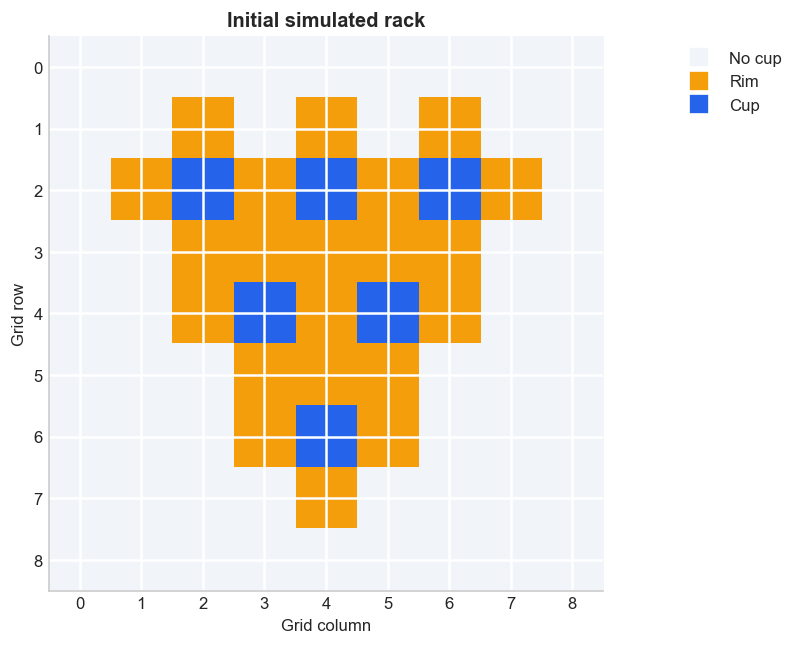

In [38]:
def plot_rack(rack: Rack, title: str = "Initial simulated rack") -> None:
    cmap = ListedColormap(["#f1f5f9", "#f59e0b", "#2563eb"])
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(rack.grid, cmap=cmap, vmin=MISS, vmax=CUP)
    ax.set(
        title=title,
        xlabel="Grid column",
        ylabel="Grid row",
        xticks=range(GRID_SIZE),
        yticks=range(GRID_SIZE),
    )
    ax.grid(color="white", linewidth=1.5)
    legend = [
        plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=color,
                   markersize=12, label=label)
        for color, label in [
            ("#f1f5f9", "No cup"),
            ("#f59e0b", "Rim"),
            ("#2563eb", "Cup"),
        ]
    ]
    ax.legend(handles=legend, loc="upper right", bbox_to_anchor=(1.35, 1.0))
    plt.show()


rack = Rack()
assert rack.cups_remaining == WINNING_SCORE
assert np.count_nonzero(rack.grid == RIM) == len(RIM_COORDINATES)

smoke_test = simulate_game(first_player=1, rng=np.random.default_rng(SEED))
assert WINNING_SCORE in smoke_test.final_scores
assert len(smoke_test.event_times[smoke_test.winner - 1]) == WINNING_SCORE
assert set(r.shot_kind for r in smoke_test.records) <= {
    "Direct miss", "Direct cup", "Rim, then miss", "Rim, then cup"
}

plot_rack(rack)

## 4. One score trajectory

The paper defines $P_t$ as one player's cumulative score after that player's $t^{\text{th}}$ attempt. The plot below shows a reproducible winning trajectory and uses a step plot because the process increases by one only when a cup is made.

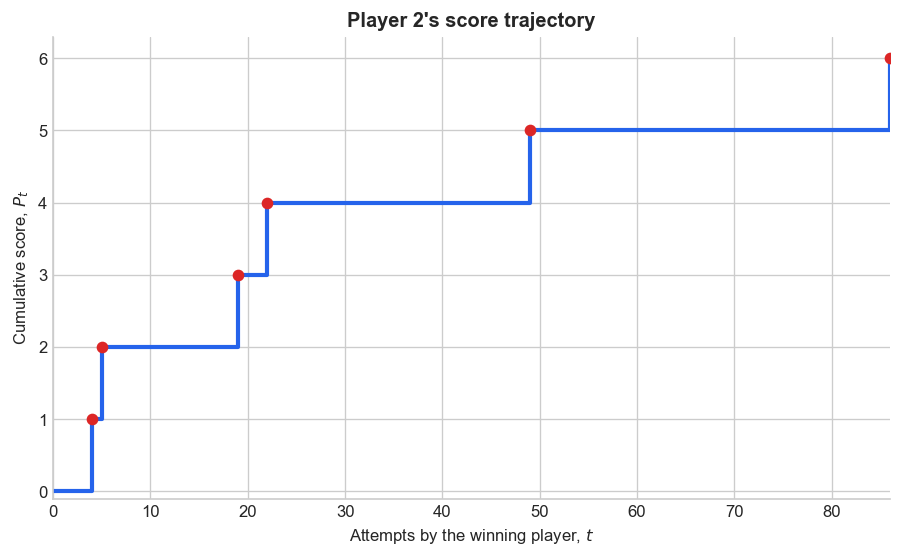

,global_throw,player,player_attempt,shot_kind,scored,player1_score,player2_score
0,1,1,1,Direct cup,True,1,0
1,2,1,2,Direct miss,False,1,0
2,3,2,1,Direct miss,False,1,0
3,4,1,3,Direct miss,False,1,0
4,5,2,2,"Rim, then miss",False,1,0
5,6,1,4,Direct miss,False,1,0
6,7,2,3,Direct miss,False,1,0
7,8,1,5,Direct miss,False,1,0
8,9,2,4,"Rim, then cup",True,1,1
9,10,2,5,"Rim, then cup",True,1,2


In [48]:
sample_game = simulate_game(first_player=1, rng=np.random.default_rng(2042))
winner_index = sample_game.winner - 1
winner_events = np.array(sample_game.event_times[winner_index])
final_attempt = sample_game.attempts[winner_index]

t_sample = np.arange(final_attempt + 1)
score_sample = np.searchsorted(winner_events, t_sample, side="right")

fig, ax = plt.subplots()
ax.step(t_sample, score_sample, where="post", linewidth=2.5, color="#2563eb")
ax.scatter(winner_events, np.arange(1, WINNING_SCORE + 1), color="#dc2626", zorder=3)
ax.set(
    title=f"Player {sample_game.winner}'s score trajectory",
    xlabel="Attempts by the winning player, $t$",
    ylabel="Cumulative score, $P_t$",
    xlim=(0, final_attempt),
    ylim=(-0.1, WINNING_SCORE + 0.3),
    yticks=range(WINNING_SCORE + 1),
)
plt.show()

sample_game.history_frame().head(10)

## 5. Many-game summaries

- **Neck and neck:** largest lead at most 3;
- **Apparent choke:** largest lead above 3, final margin at most 3;
- **Landslide:** largest lead above 3, final margin above 3.

In [40]:
def simulate_many_games(
    n_games: int,
    *,
    seed: int = SEED,
    first_player: int | None = None,
) -> pd.DataFrame:
    '''Return one tidy summary row per simulated game.'''
    rng = np.random.default_rng(seed)
    rows = []

    for game_id in range(n_games):
        starter = int(rng.integers(1, 3)) if first_player is None else first_player
        result = simulate_game(starter, rng=rng)
        shot_counts = Counter(record.shot_kind for record in result.records)
        n_throws = len(result.records)

        rows.append({
            "game_id": game_id,
            "first_player": starter,
            "winner": result.winner,
            "player1_score": result.final_scores[0],
            "player2_score": result.final_scores[1],
            "total_throws": n_throws,
            "player1_attempts": result.attempts[0],
            "player2_attempts": result.attempts[1],
            "attempt_difference": result.attempts[0] - result.attempts[1],
            "max_absolute_lead": result.max_absolute_lead,
            "final_margin": result.final_margin,
            "game_type": result.game_type,
            "surprise_type": result.surprise_type,
            **{
                f"share_{kind.lower().replace(', ', '_').replace(' ', '_')}":
                    shot_counts[kind] / n_throws
                for kind in (
                    "Direct miss", "Direct cup",
                    "Rim, then miss", "Rim, then cup",
                )
            },
        })

    return pd.DataFrame(rows)


games = simulate_many_games(10_000, seed=SEED)
games.head()

,game_id,first_player,winner,player1_score,player2_score,total_throws,player1_attempts,player2_attempts,attempt_difference,max_absolute_lead,final_margin,game_type,surprise_type,share_direct_miss,share_direct_cup,share_rim_then_miss,share_rim_then_cup
0,0,1,2,4,6,157,78,79,-1,3,2,Neck and neck,No surprise,0.853503,0.031847,0.082803,0.031847
1,1,2,2,5,6,149,74,75,-1,1,1,Neck and neck,Other,0.845638,0.026846,0.080537,0.046980
2,2,1,1,6,5,107,54,53,1,1,1,Neck and neck,Other,0.803738,0.046729,0.093458,0.056075
3,3,1,1,6,5,133,67,66,1,4,1,Apparent choke,No surprise,0.827068,0.030075,0.090226,0.052632
4,4,2,1,6,4,81,41,40,1,2,2,Neck and neck,Other,0.827160,0.061728,0.049383,0.061728


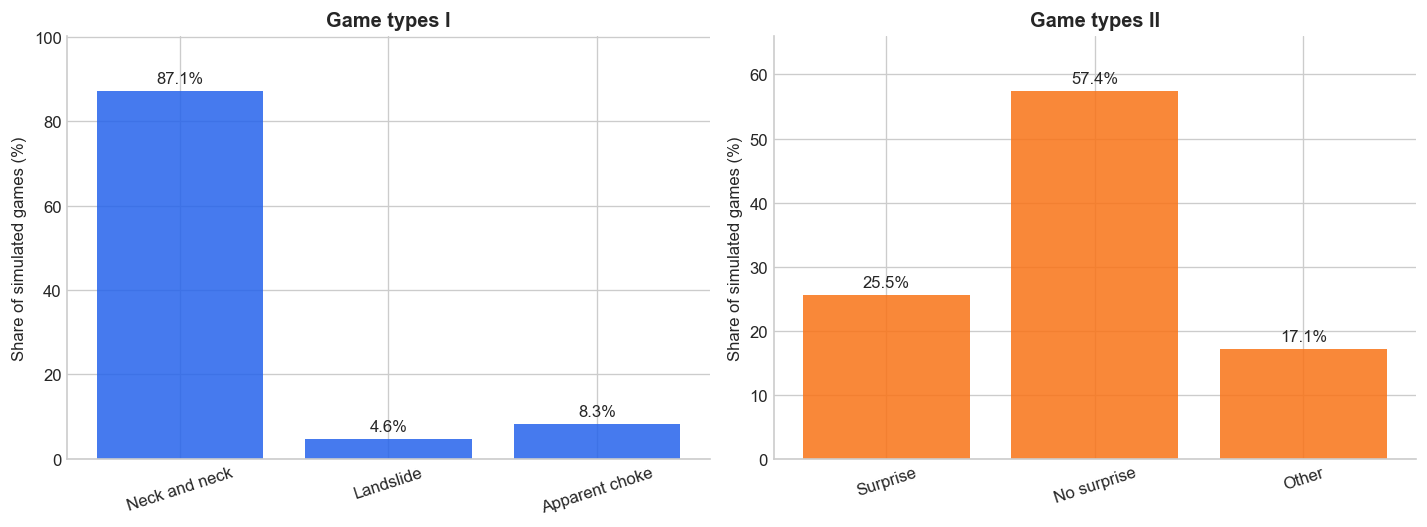

,estimate
Player 1 win rate,0.4896
Mean final margin,1.6371
Mean total throws,132.3504
P(apparent choke | lead > 3),0.6460


,proportion,percent
game_type,,
Neck and neck,0.8709,87.09
Landslide,0.0457,4.57
Apparent choke,0.0834,8.34


In [50]:
def proportion_table(series: pd.Series, order: Iterable[str]) -> pd.DataFrame:
    proportions = series.value_counts(normalize=True).reindex(order, fill_value=0.0)
    return proportions.rename("proportion").to_frame().assign(
        percent=lambda frame: 100 * frame["proportion"]
    )


game_types = proportion_table(
    games["game_type"],
    ["Neck and neck", "Landslide", "Apparent choke"],
)
surprise_types = proportion_table(
    games["surprise_type"],
    ["Surprise", "No surprise", "Other"],
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, table, title, color in [
    (axes[0], game_types, "Game types I", "#2563eb"),
    (axes[1], surprise_types, "Game types II", "#f97316"),
]:
    bars = ax.bar(table.index, table["percent"], color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set(title=title, ylabel="Share of simulated games (%)")
    ax.tick_params(axis="x", rotation=18)
    ax.set_ylim(0, max(table["percent"]) * 1.15)
plt.tight_layout()
plt.show()

summary = pd.Series({
    "Player 1 win rate": (games["winner"] == 1).mean(),
    "Mean final margin": games["final_margin"].mean(),
    "Mean total throws": games["total_throws"].mean(),
    "P(apparent choke | lead > 3)": (
        (games["game_type"] == "Apparent choke").sum()
        / (games["max_absolute_lead"] > 3).sum()
    ),
})
display(summary.to_frame("estimate").style.format("{:.4f}"))
display(game_types.style.format({"proportion": "{:.4f}", "percent": "{:.2f}"}))

## 6. Estimating unconditional rack-clearing event times

To model a single player's rack-clearing process without conditioning on winning a two-player game, we simulate one player repeatedly throwing until all six cups have been made.

Each simulation produces six event times,

$$
(T_1,T_2,\ldots,T_6),
$$

where $T_n$ is the number of attempts required to score the $n$th point.

Repeating this experiment many times gives an unconditional sample of rack-clearing trajectories. We then estimate the mean event times,

$$
t_n=E[T_n],
$$

by averaging the corresponding event times across all simulations.

In [42]:
def simulate_rack_clearance(
    *,
    rng: np.random.Generator | None = None,
) -> tuple[int, ...]:
    """Throw at one rack until all six cups have been cleared."""
    rng = np.random.default_rng() if rng is None else rng
    rack = Rack()

    attempts = 0
    event_times = []

    while rack.cups_remaining > 0:
        attempts += 1
        shot = simulate_shot(rack, rng)

        if shot.scored:
            event_times.append(attempts)

    return tuple(event_times)

def collect_unconditional_event_times(
    n_runs: int,
    *,
    seed: int,
) -> np.ndarray:
    """Collect six event times from independent rack-clearance simulations."""
    rng = np.random.default_rng(seed)

    event_times = [
        simulate_rack_clearance(
            rng=rng,
        )
        for _ in range(n_runs)
    ]

    return np.asarray(event_times, dtype=int)

unconditional_events = collect_unconditional_event_times(
    10_000,
    seed=2101,
)

unconditional_mean_times = unconditional_events.mean(axis=0)

In [43]:
unconditional_mean_times

array([ 4.9052, 11.2322, 19.6792, 31.7763, 50.9177, 90.8531])

## 7. Intensity $\lambda(t)$

Each interval between successive mean event times contains one expected score. Approximating the intensity as constant on an interval gives

$$
\lambda_i \approx \frac{1}{t_i-t_{i-1}}.
$$


$$
\lambda(t)=Ce^{rt}
$$

$$
\log \lambda(t)=\log C+rt,
$$

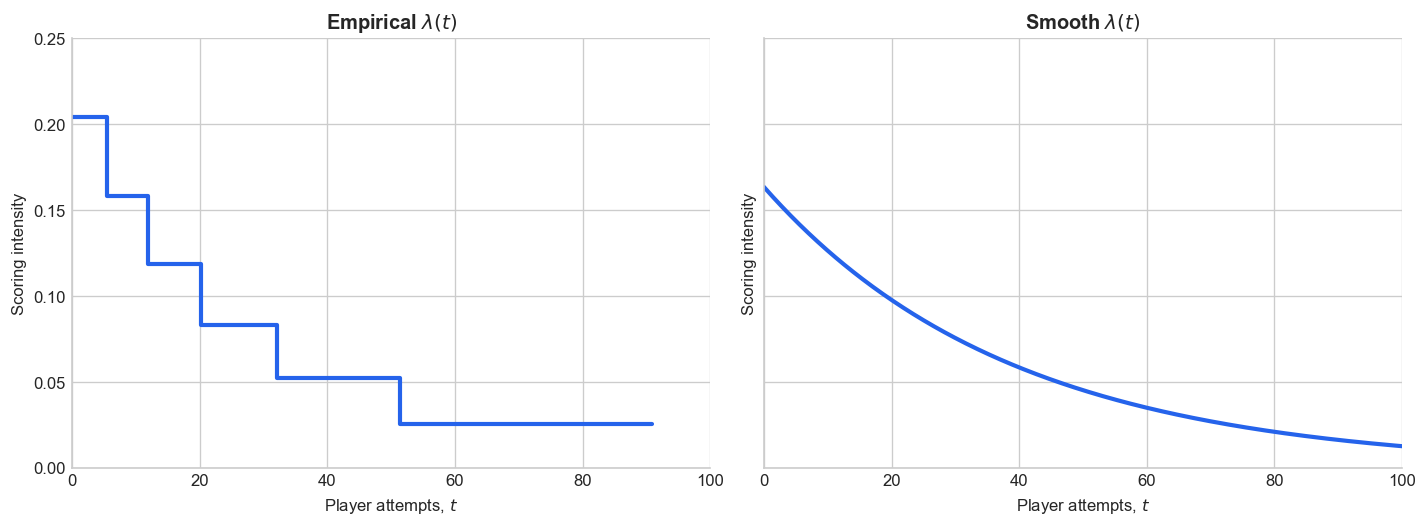

Fitted intensity: lambda(t) = 0.163349587480195 * exp(-0.02578022137 t)


In [52]:
def stepwise_intensity(
    t: np.ndarray,
    event_time_boundaries: np.ndarray,
) -> np.ndarray:
    levels = 1.0 / np.diff(event_time_boundaries)
    interval = np.searchsorted(event_time_boundaries[1:], t, side="left")
    return levels[np.clip(interval, 0, len(levels) - 1)]

event_time_boundaries = np.concatenate([
    [0.0],
    unconditional_mean_times,
])
FIT_END = event_time_boundaries[-1]  # approximately 90.8531
PLOT_END = 100

t_fit = np.linspace(
    0,
    FIT_END,
    100,
)

lambda_step = stepwise_intensity(
    t_fit,
    event_time_boundaries,
)

decay_rate, log_scale = np.polyfit(t_fit, np.log(lambda_step), deg=1)
scale = float(np.exp(log_scale))

def smooth_intensity(t: np.ndarray | float) -> np.ndarray:
    return scale * np.exp(decay_rate * np.asarray(t))


t_plot = np.linspace(
    0,
    PLOT_END,
    500,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].step(
    t_fit, lambda_step, where="post", linewidth=2.5, color="#2563eb"
)
axes[0].set(title="Empirical $\\lambda(t)$")
axes[1].plot(t_plot, smooth_intensity(t_plot), linewidth=2.5, color="#2563eb")
axes[1].set(title="Smooth $\\lambda(t)$")

for ax in axes:
    ax.set(xlabel="Player attempts, $t$", ylabel="Scoring intensity")
    ax.set_xlim(0, PLOT_END)
    ax.set_ylim(0, 0.25)
plt.tight_layout()
plt.show()

print(f"Fitted intensity: lambda(t) = {scale:.15f} * exp({decay_rate:.11f} t)")

## 8. Expected score $m(t)$

For a non-homogeneous Poisson process,

$$
m(t)=E[P_t]=\int_0^t \lambda(s)\,ds
=\frac{C}{r}\left(e^{rt}-1\right).
$$

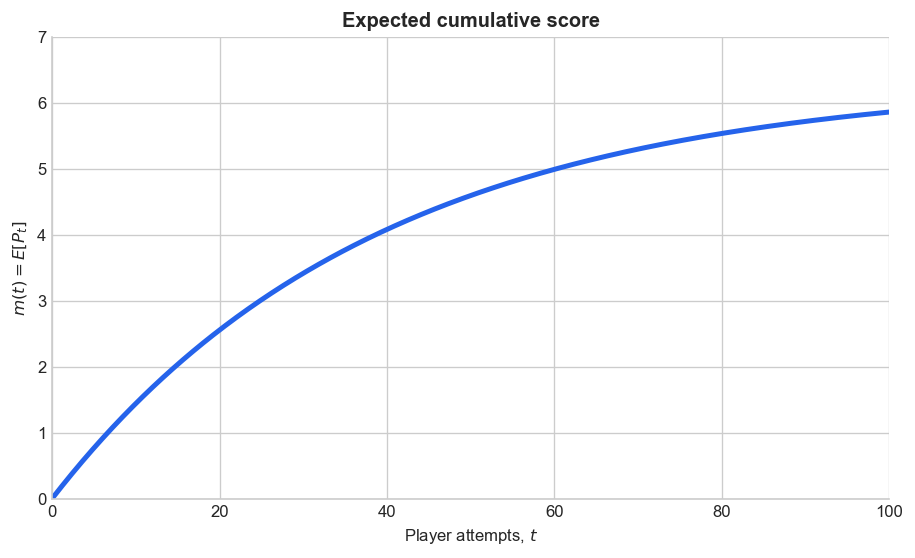

In [53]:
def expected_score(t: np.ndarray | float) -> np.ndarray:
    t = np.asarray(t)
    return (scale / decay_rate) * (np.exp(decay_rate * t) - 1.0)


fig, ax = plt.subplots()
ax.plot(t_plot, expected_score(t_plot), linewidth=3, color="#2563eb")
ax.set(
    title="Expected cumulative score",
    xlabel="Player attempts, $t$",
    ylabel="$m(t)=E[P_t]$",
    xlim=(0, PLOT_END),
    ylim=(0, 7),
)
plt.show()

## 9. $P(P_t=n)$ for $n=1,\ldots,6$

Under the nonhomogeneous Poisson approximation,

$$
P(P_t=n)=\frac{m(t)^n}{n!}e^{-m(t)}.
$$

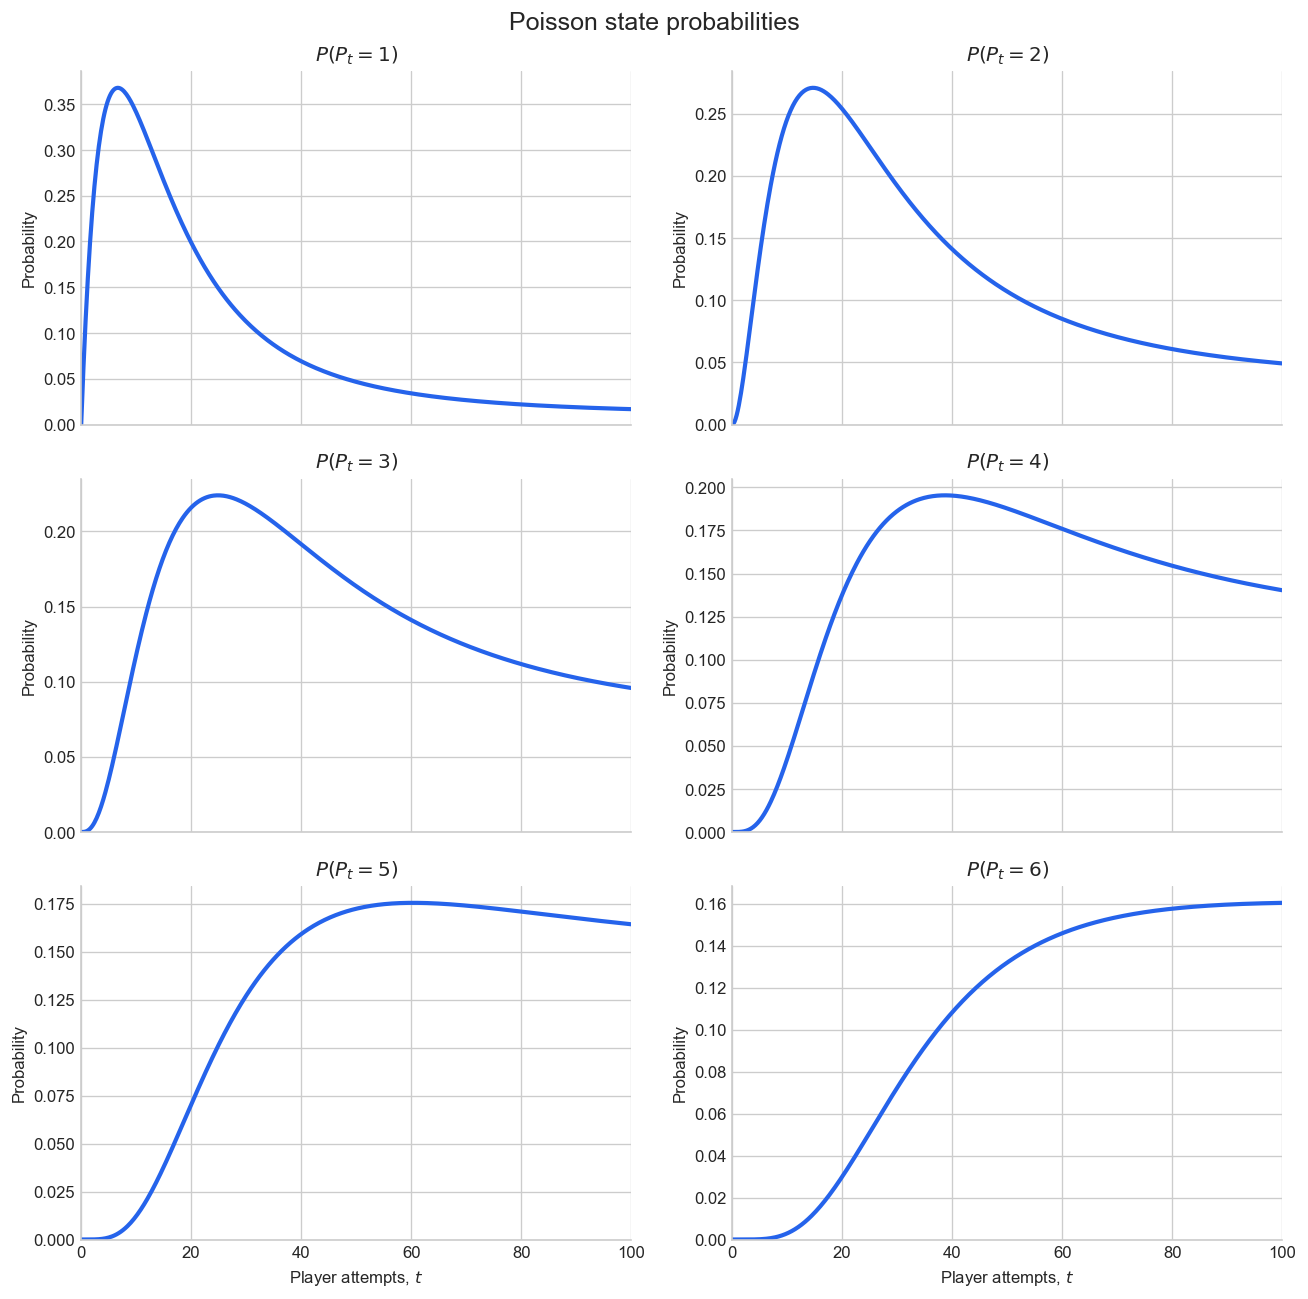

In [55]:
def poisson_state_probability(t: np.ndarray, n: int) -> np.ndarray:
    mean = expected_score(t)
    return np.power(mean, n) * np.exp(-mean) / factorial(n)


fig, axes = plt.subplots(3, 2, figsize=(11, 11), sharex=True)
for n, ax in enumerate(axes.flat, start=1):
    ax.plot(t_plot, poisson_state_probability(t_plot, n),
            linewidth=2.5, color="#2563eb")
    ax.set(title=rf"$P(P_t={n})$", ylabel="Probability")
    ax.set_xlim(0, PLOT_END)
    ax.set_ylim(bottom=0)
for ax in axes[-1]:
    ax.set_xlabel("Player attempts, $t$")
fig.suptitle("Poisson state probabilities", fontsize=15)
plt.tight_layout()
plt.show()

## 10. Held-out goodness of fit

To evaluate the unconditional rack-clearing model:

1. keep the fitted expected-score function $m(t)$ fixed;
2. generate an independently seeded holdout sample of one-player rack clearances;
3. calculate the mean cumulative score at each attempt; and
4. compare that empirical mean curve with $m(t)$.

The holdout simulations were not used to estimate the event-time boundaries or fit the smooth intensity function. Therefore, this tests how well the fitted model generalizes to newly simulated rack clearances.

The comparison includes $R^2$, RMSE, MAE, a pointwise approximate 95% confidence interval, and a residual plot. Because both curves are cumulative and increasing, $R^2$ should be considered alongside the error metrics and residuals.

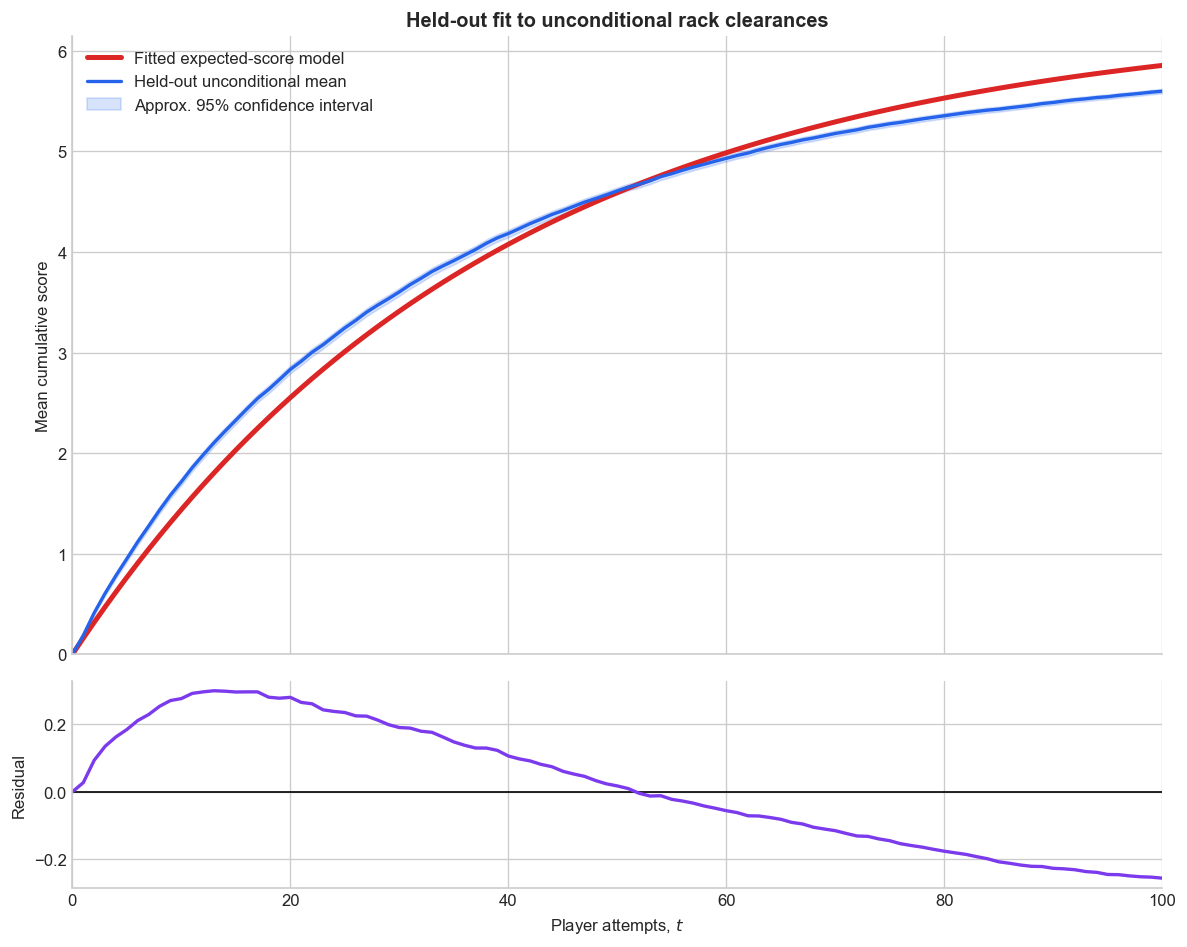

,value
R-squared,0.984722
RMSE (points),0.183202
MAE (points),0.160996
Maximum absolute error (points),0.300000
Holdout rack clearances,3000.000000


In [56]:
# Generate new unconditional rack-clearance trajectories using a different seed.
holdout_events = collect_unconditional_event_times(
    3_000,
    seed=2202,
)

# Evaluate every integer attempt across the plotting range.
t_holdout = np.arange(0, int(PLOT_END) + 1)

# For each simulated rack and time t, the score is the number of
# scoring-event times less than or equal to t.
holdout_scores = (
    holdout_events[:, :, None] <= t_holdout[None, None, :]
).sum(axis=1)

empirical_mean = holdout_scores.mean(axis=0)

standard_error = (
    holdout_scores.std(axis=0, ddof=1)
    / np.sqrt(len(holdout_scores))
)

predicted_mean = expected_score(t_holdout)
residuals = empirical_mean - predicted_mean


# Goodness-of-fit statistics
ss_residual = np.sum(np.square(residuals))
ss_total = np.sum(
    np.square(empirical_mean - empirical_mean.mean())
)

r_squared = 1.0 - ss_residual / ss_total
rmse = float(np.sqrt(np.mean(np.square(residuals))))
mae = float(np.mean(np.abs(residuals)))
max_error = float(np.max(np.abs(residuals)))


# Plot the fitted model, holdout mean, confidence interval, and residuals.
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

axes[0].plot(
    t_holdout,
    predicted_mean,
    linewidth=3,
    color="#dc2626",
    label="Fitted expected-score model",
)

axes[0].plot(
    t_holdout,
    empirical_mean,
    linewidth=2,
    color="#2563eb",
    label="Held-out unconditional mean",
)

axes[0].fill_between(
    t_holdout,
    empirical_mean - 1.96 * standard_error,
    empirical_mean + 1.96 * standard_error,
    color="#2563eb",
    alpha=0.18,
    label="Approx. 95% confidence interval",
)

axes[0].set(
    ylabel="Mean cumulative score",
    title="Held-out fit to unconditional rack clearances",
)

axes[0].set_xlim(0, PLOT_END)
axes[0].set_ylim(bottom=0)
axes[0].legend()


axes[1].axhline(
    0,
    color="black",
    linewidth=1,
)

axes[1].plot(
    t_holdout,
    residuals,
    color="#7c3aed",
    linewidth=2,
)

axes[1].set(
    xlabel="Player attempts, $t$",
    ylabel="Residual",
)

axes[1].set_xlim(0, PLOT_END)

plt.tight_layout()
plt.show()


goodness_of_fit = pd.Series({
    "R-squared": r_squared,
    "RMSE (points)": rmse,
    "MAE (points)": mae,
    "Maximum absolute error (points)": max_error,
    "Holdout rack clearances": len(holdout_events),
})

display(
    goodness_of_fit
    .to_frame("value")
    .style.format("{:.6f}")
)

## 11. Interpretation

- The simulation can produce games that look like psychological “choking” even though players have no psychology, skill, or memory. In the model, scoring becomes harder as cups and useful rim geometry disappear, allowing an opponent to catch up through probability alone.
- The held-out test asks whether the smooth expected-score curve reproduces new Monte Carlo output generated under the same rules.
- A strong fit supports the analytical approximation **to this simulator**. A claim about real beer pong would require observed game data and an out-of-model validation sample.